In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/cicd_data.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nFailed vs Passed:")
print(df['failed'].value_counts())
print("\nStats:")
print(df.describe())

Shape: (30, 10)

First 5 rows:
   build_id  commit_size  files_changed  test_count  code_coverage  \
0         1          150              5         120             85   
1         2          320             12         118             83   
2         3          890             34         115             78   
3         4          120              4         122             87   
4         5          450             18         110             75   

   hour_of_day  day_of_week  prev_build_failed  build_duration_mins  failed  
0           10            1                  0                    8       0  
1           14            2                  0                   12       0  
2           16            3                  0                   25       1  
3            9            1                  0                    7       0  
4           17            4                  1                   35       1  

Failed vs Passed:
failed
0    18
1    12
Name: count, dtype: int64

Stats:
    

In [4]:
print("Average values — Failed builds:")
print(df[df['failed']==1][['commit_size','files_changed','code_coverage','prev_build_failed']].mean())

print("\nAverage values — Passed builds:")
print(df[df['failed']==0][['commit_size','files_changed','code_coverage','prev_build_failed']].mean())

Average values — Failed builds:
commit_size          740.833333
files_changed         29.833333
code_coverage         72.416667
prev_build_failed      0.916667
dtype: float64

Average values — Passed builds:
commit_size          206.666667
files_changed          7.833333
code_coverage         84.555556
prev_build_failed      0.000000
dtype: float64


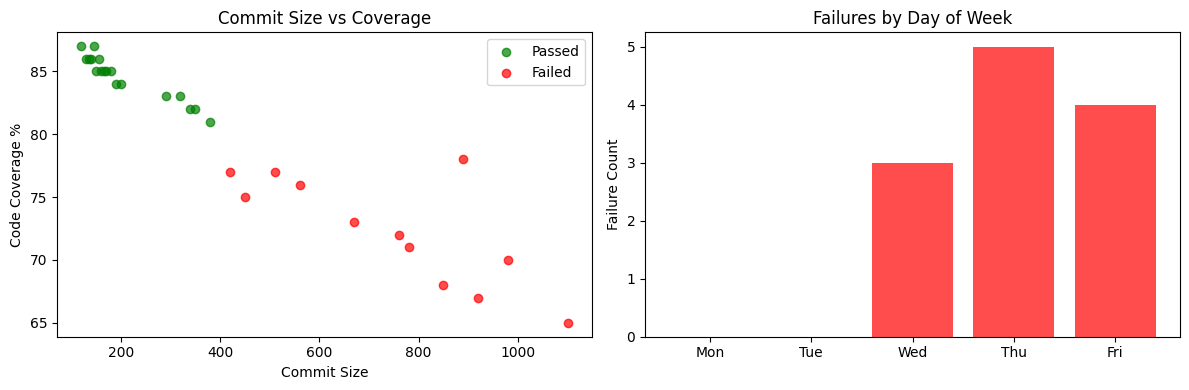

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1 — commit size vs coverage (unchanged)
axes[0].scatter(
    df[df['failed']==0]['commit_size'],
    df[df['failed']==0]['code_coverage'],
    color='green', label='Passed', alpha=0.7
)
axes[0].scatter(
    df[df['failed']==1]['commit_size'],
    df[df['failed']==1]['code_coverage'],
    color='red', label='Failed', alpha=0.7
)
axes[0].set_xlabel('Commit Size')
axes[0].set_ylabel('Code Coverage %')
axes[0].set_title('Commit Size vs Coverage')
axes[0].legend()

# Chart 2 — FIXED version
day_map = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri'}

# Count failures for ALL 5 days — fill missing days with 0
failed_by_day = (
    df[df['failed']==1]['day_of_week']
    .value_counts()
    .reindex([1, 2, 3, 4, 5], fill_value=0)  # ← fills missing days with 0
    .sort_index()
)

axes[1].bar(
    [day_map[d] for d in failed_by_day.index],  # ← convert numbers to names
    failed_by_day.values,
    color='red', alpha=0.7
)
axes[1].set_title('Failures by Day of Week')
axes[1].set_ylabel('Failure Count')

plt.tight_layout()
plt.show()